In [2]:
from itertools import dropwhile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =  pd.read_csv("/Users/golisairam/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()
(df == " ").sum()

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(float)
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df.isnull().sum()



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [3]:
# Load dataset
df = pd.read_csv("/Users/golisairam/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(float)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Feature Engineering
def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 24:
        return "13-24 Months"
    elif tenure <= 48:
        return "25-48 Months"
    else:
        return "48+ Months"

df["TenureGroup"] = df["tenure"].apply(tenure_group)

# Avoid divide by zero
df["AvgMonthlySpend"] = (
    df["TotalCharges"] / df["tenure"].replace(0, 1)
)

# Binary Encoding
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_cols:
    df[col] = df[col].astype(str).str.strip()

    df[col] = df[col].replace({
        "Yes": 1,
        "No": 0
    })

# Verify
print(df["Churn"].unique())
print(df["Churn"].value_counts())

[0 1]
Churn
0    5174
1    1869
Name: count, dtype: int64


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])

In [5]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'AvgMonthlySpend']


In [5]:
categorical_cols = ["Contract", "InternetService", "PaymentMethod"]

# Keep only columns that actually exist
existing_cols = [col for col in categorical_cols if col in df.columns]

print("Existing columns:", existing_cols)

df = pd.get_dummies(
    df,
    columns=existing_cols,
    drop_first=True
)
print(df.columns.tolist())

Existing columns: ['Contract', 'InternetService', 'PaymentMethod']
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'AvgMonthlySpend', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [6]:
print(df["Churn"].unique())
print(df["Churn"].value_counts())

[0 1]
Churn
0    5174
1    1869
Name: count, dtype: int64


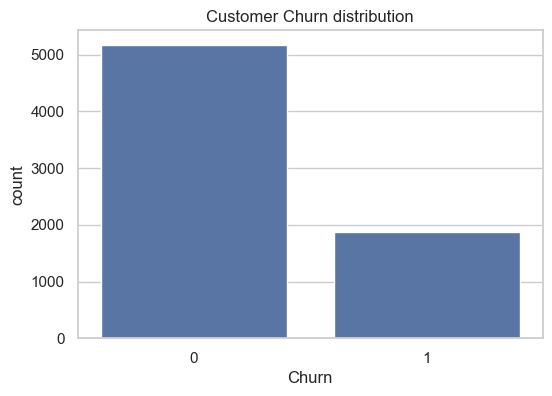

In [7]:
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(x="Churn",df="")
plt.title("Customer Churn distribution")
plt.show()

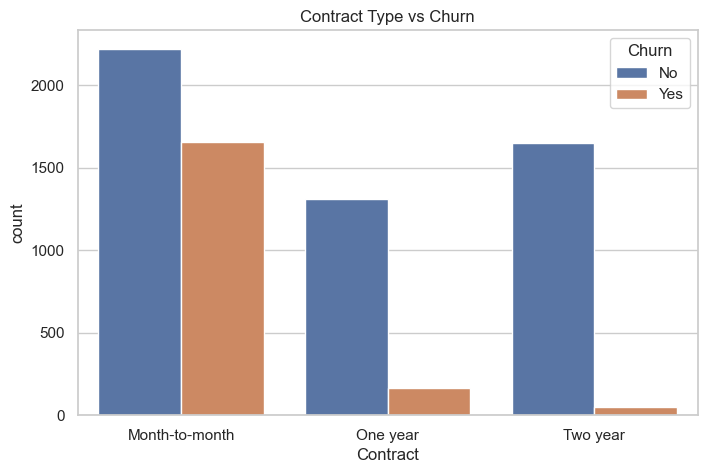

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=pd.read_csv("/Users/golisairam/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
)

plt.title("Contract Type vs Churn")

plt.show()

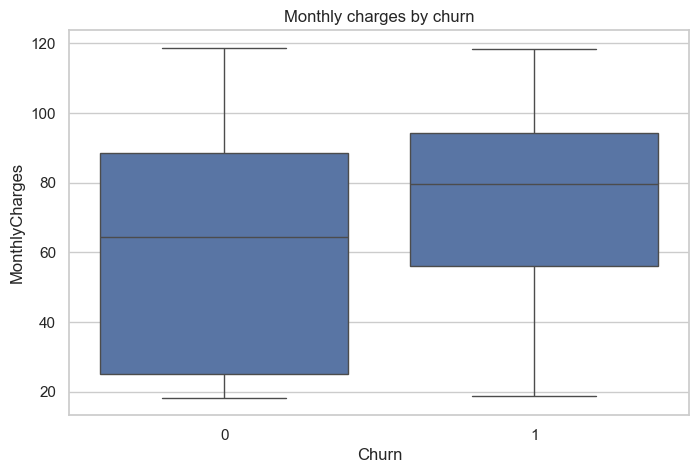

In [14]:
#box plot

plt.figure(figsize=(8,5))
sns.boxplot( x = "Churn",
              y = "MonthlyCharges",
              data = df
)
plt.title("Monthly charges by churn")
plt.show()


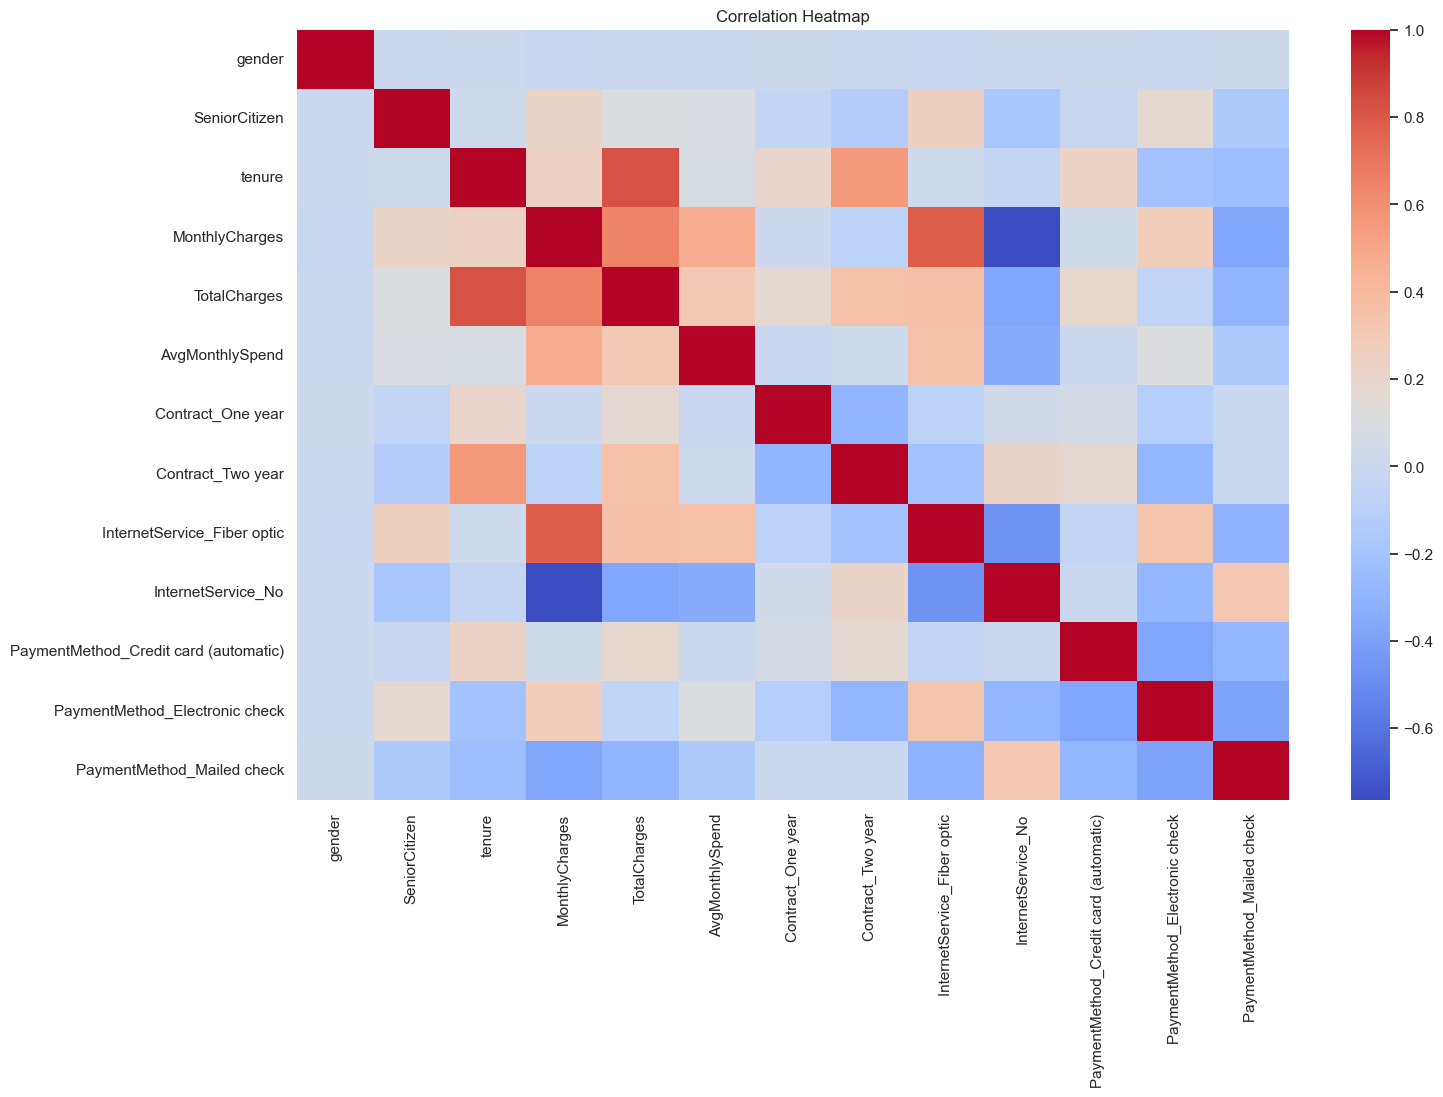

In [15]:
#Heatmap of correlations


plt.figure(figsize=(16,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
df.to_csv("cleaned_customer_churn.csv", index=False)